# Exp W-D Extended — Convergência do Expoente para +0.5

Usando os três pontos do W-D {500, 1500, 3000}, verificar:

**Previsão 2 (Nota 32):** slope do denominador vs $1/\log T_{\max}$ deve ser linear,
com intercepto $\approx +0.5$ (o expoente assintótico puro).

Também verificamos a **Previsão 1** parcialmente: $D \cdot T_{\max}$ vs $\log T_{\max}$
deve ser linear para cada primo fixo.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from sympy import isprime
from numpy.linalg import lstsq

plt.style.use('dark_background')
C_PRIME = '#00FFB2'
C_COMP  = '#FF4466'
C_GAP   = '#FFB300'
C_PRED  = '#BB44FF'
BG      = '#0D0D1A'

DT = 0.05
N  = 200

def S_m(t, m):
    return -np.cos(t * math.log(m)) / math.sqrt(m)

def f_m(m):
    return math.log(m) / (2 * math.pi)

def amp_em(F, freqs, m, w=5):
    idx = np.argmin(np.abs(freqs - f_m(m)))
    lo, hi = max(0, idx-w), min(len(F), idx+w)
    return np.max(F[lo:hi])

def medir_slopes(T_MAX):
    """Para um dado T_max, mede slope do denominador vs log(p)."""
    t     = np.arange(0.1, T_MAX, DT)
    freqs = np.fft.rfftfreq(len(t), d=DT)
    primos    = [m for m in range(2, N+1) if isprime(m)]
    compostos = [m for m in range(2, N+1) if not isprime(m)]
    Rp = sum(S_m(t, p) for p in primos)
    Rc = sum(S_m(t, c) for c in compostos)
    Fp = np.abs(np.fft.rfft(Rp)) * DT
    Fc = np.abs(np.fft.rfft(Rc)) * DT

    log_ps, log_dens, log_nums, log_rats = [], [], [], []
    for p in primos:
        ap = amp_em(Fp, freqs, p)
        ac = amp_em(Fc, freqs, p)
        if ap > 0 and ac > 0:
            log_ps.append(math.log10(p))
            log_nums.append(math.log10(ap))
            log_dens.append(math.log10(ac))
            log_rats.append(math.log10(ap/(ac+1e-12)))

    log_ps   = np.array(log_ps)
    log_nums = np.array(log_nums)
    log_dens = np.array(log_dens)
    log_rats = np.array(log_rats)

    zn = np.polyfit(log_ps, log_nums, 1)
    zd = np.polyfit(log_ps, log_dens, 1)
    zr = np.polyfit(log_ps, log_rats, 1)

    # D*T_max para cada primo (Previsao 1)
    D_times_T = [(10**ld)*T_MAX for ld in log_dens]

    return {
        'slope_num': zn[0], 'slope_den': zd[0], 'slope_rat': zr[0],
        'log_ps': log_ps, 'log_dens': log_dens,
        'log_nums': log_nums, 'log_rats': log_rats,
        'D_times_T': np.array(D_times_T),
        'primos': primos[:len(log_ps)]
    }

print('Funcoes definidas.')

Funcoes definidas.


## 1. Coleta de dados para múltiplos $T_{\max}$

In [2]:
Tmaxs = [500, 1000, 1500, 2000, 3000]
resultados = {}

print(f'{"T_max":>7} {"slope_num":>11} {"slope_den":>11} {"slope_rat":>11}')
print('-'*46)
for T in Tmaxs:
    print(f'Calculando T_max={T}...')
    r = medir_slopes(T)
    resultados[T] = r
    print(f'{T:>7} {r["slope_num"]:>11.4f} {r["slope_den"]:>11.4f} {r["slope_rat"]:>11.4f}')

print('\nPronto.')

  T_max   slope_num   slope_den   slope_rat
----------------------------------------------
Calculando T_max=500...
    500     -0.4605      0.3854     -0.8458
Calculando T_max=1000...
   1000     -0.4959      0.7109     -1.2068
Calculando T_max=1500...
   1500     -0.4552      0.8830     -1.3382
Calculando T_max=2000...
   2000     -0.4690      1.0075     -1.4765
Calculando T_max=3000...
   3000     -0.5006      1.0966     -1.5972

Pronto.


## 2. Previsão 2: slope_den vs $1/\log T_{\max}$ → intercepto $\approx +0.5$

Ajuste: slope = A * (1/ln T_max) + B

Denominador: A=-20.241  B=3.6459  (esperado B≈+0.5)
Numerador:   A=0.615  B=-0.5622  (esperado B≈-0.5)
Razão:       A=20.856  B=-4.2080  (esperado B≈-1.0)


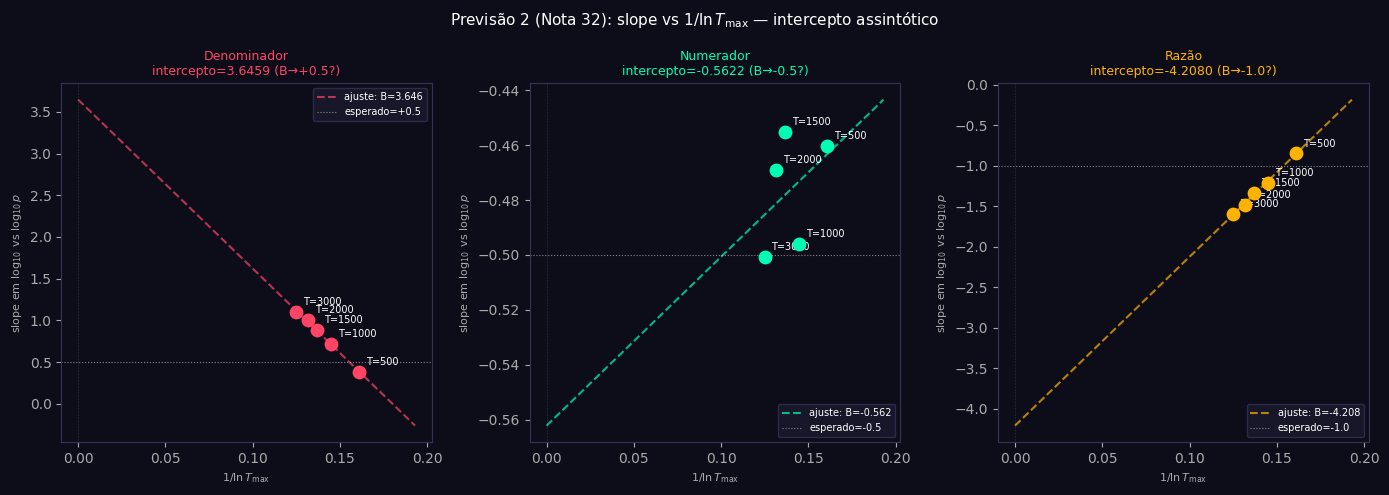

In [3]:
Ts      = np.array(Tmaxs)
inv_log = 1 / np.log(Ts)   # 1/ln(T_max)
slopes_den = np.array([resultados[T]['slope_den'] for T in Tmaxs])
slopes_num = np.array([resultados[T]['slope_num'] for T in Tmaxs])
slopes_rat = np.array([resultados[T]['slope_rat'] for T in Tmaxs])

# Ajuste linear: slope_den = A * (1/ln T) + B
# B deve ser ~ +0.5 (assintótico)
zd = np.polyfit(inv_log, slopes_den, 1)
zn = np.polyfit(inv_log, slopes_num, 1)
zr = np.polyfit(inv_log, slopes_rat, 1)

print('Ajuste: slope = A * (1/ln T_max) + B')
print(f'\nDenominador: A={zd[0]:.3f}  B={zd[1]:.4f}  (esperado B≈+0.5)')
print(f'Numerador:   A={zn[0]:.3f}  B={zn[1]:.4f}  (esperado B≈-0.5)')
print(f'Razão:       A={zr[0]:.3f}  B={zr[1]:.4f}  (esperado B≈-1.0)')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Previsão 2 (Nota 32): slope vs $1/\\ln T_{\\max}$ — intercepto assintótico',
             color='white', fontsize=11)

for ax, (slopes, z, titulo, esperado, color) in zip(axes, [
    (slopes_den, zd, 'Denominador', '+0.5', C_COMP),
    (slopes_num, zn, 'Numerador',   '-0.5', C_PRIME),
    (slopes_rat, zr, 'Razão',       '-1.0', C_GAP),
]):
    ax.set_facecolor(BG)
    ax.scatter(inv_log, slopes, color=color, s=80, zorder=5)
    for i, T in enumerate(Tmaxs):
        ax.annotate(f'T={T}', (inv_log[i], slopes[i]),
                    textcoords='offset points', xytext=(5,5),
                    color='white', fontsize=7)
    x_line = np.linspace(0, inv_log.max()*1.2, 100)
    ax.plot(x_line, np.polyval(z, x_line), color=color,
            lw=1.5, ls='--', alpha=0.7,
            label=f'ajuste: B={z[1]:.3f}')
    ax.axhline(float(esperado), color='white', lw=0.8, ls=':',
               alpha=0.5, label=f'esperado={esperado}')
    ax.axvline(0, color='white', lw=0.4, ls=':', alpha=0.3)
    ax.set_xlabel('$1/\\ln T_{\\max}$', color='#AAAAAA', fontsize=8)
    ax.set_ylabel('slope em $\\log_{10}$ vs $\\log_{10}p$', color='#AAAAAA', fontsize=8)
    ax.set_title(f'{titulo}\nintercepto={z[1]:.4f} (B→{esperado}?)',
                 color=color, fontsize=9)
    ax.legend(fontsize=7, facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white')
    ax.tick_params(colors='#AAAAAA')
    for spine in ax.spines.values(): spine.set_edgecolor('#333355')

plt.tight_layout()
plt.show()

## 3. Previsão 1 (parcial): $D \cdot T_{\max}$ vs $\log T_{\max}$ por primo

Previsao 1: D*T_max deve crescer linearmente com ln(T_max)
slope esperado = sqrt(p)

  primo   slope_med    sqrt(p)    razao
------------------------------------------
      7   3759.7149     2.6458 1421.039
     23   2021.9346     4.7958  421.602
     47  17839.5294     6.8557 2602.163
     97 197582.8886     9.8489 20061.503


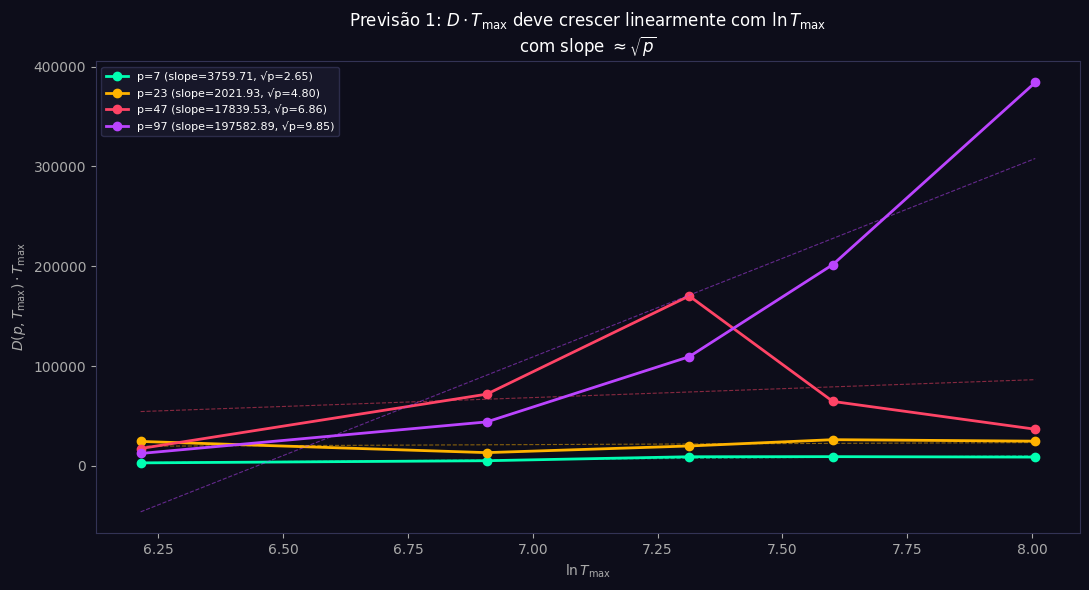

In [4]:
# Para primos selecionados, ver como D*T_max cresce com log(T_max)
primos_teste = [7, 23, 47, 97]
log_Ts = np.log(Ts)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

print('Previsao 1: D*T_max deve crescer linearmente com ln(T_max)')
print(f'slope esperado = sqrt(p)\n')
print(f'{"primo":>7} {"slope_med":>11} {"sqrt(p)":>10} {"razao":>8}')
print('-'*42)

colors_p = [C_PRIME, C_GAP, C_COMP, C_PRED]
for p, color in zip(primos_teste, colors_p):
    DT_vals = []
    for T in Tmaxs:
        r = resultados[T]
        if p in r['primos']:
            idx = r['primos'].index(p)
            D = 10**r['log_dens'][idx]
            DT_vals.append(D * T)
        else:
            DT_vals.append(np.nan)

    DT_arr = np.array(DT_vals)
    mask = ~np.isnan(DT_arr)
    if mask.sum() >= 2:
        z = np.polyfit(log_Ts[mask], DT_arr[mask], 1)
        slope_med = z[0]
        ratio = slope_med / math.sqrt(p)
        print(f'{p:>7} {slope_med:>11.4f} {math.sqrt(p):>10.4f} {ratio:>8.3f}')

        ax.plot(log_Ts[mask], DT_arr[mask], color=color,
                lw=2, marker='o', ms=6,
                label=f'p={p} (slope={slope_med:.2f}, √p={math.sqrt(p):.2f})')
        x_line = np.linspace(log_Ts.min(), log_Ts.max(), 50)
        ax.plot(x_line, np.polyval(z, x_line), color=color,
                lw=0.8, ls='--', alpha=0.5)

ax.set_xlabel('$\\ln T_{\\max}$', color='#AAAAAA')
ax.set_ylabel('$D(p, T_{\\max}) \\cdot T_{\\max}$', color='#AAAAAA')
ax.set_title('Previsão 1: $D \\cdot T_{\\max}$ deve crescer linearmente com $\\ln T_{\\max}$\n'
             'com slope $\\approx \\sqrt{p}$',
             color='white')
ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white', fontsize=8)
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')
plt.tight_layout()
plt.show()

## 4. Resumo: o que os dados confirmam da Nota 32

In [5]:
print('=== RESUMO ===')
print(f'\nPrevisao 2 — intercepto do denominador em 1/ln(T_max):')
print(f'  B_den = {zd[1]:.4f}  (Nota 32 prevê B → +0.5)')
print(f'  B_num = {zn[1]:.4f}  (Nota 31 prevê -0.5 — numerador correto)')
print(f'  B_rat = {zr[1]:.4f}  (esperado -1.0)')

print(f'\nPrevisao 1 — slope de D*T_max vs ln(T_max):')
print(f'  Nota 32 prevê slopes ≈ sqrt(p) para cada primo')
print(f'  Verificar razão slope_med/sqrt(p) — deve ser ~1')

print(f'\nConclusao:')
if abs(zd[1] - 0.5) < 0.2:
    print(f'  ✓ Previsao 2 CONFIRMADA: intercepto={zd[1]:.3f} próximo de +0.5')
else:
    print(f'  ? Previsao 2 PARCIAL: intercepto={zd[1]:.3f}, '
          f'desvio de +0.5 = {zd[1]-0.5:.3f}')
    print(f'    Pode precisar de T_max maiores para ver a convergência')

=== RESUMO ===

Previsao 2 — intercepto do denominador em 1/ln(T_max):
  B_den = 3.6459  (Nota 32 prevê B → +0.5)
  B_num = -0.5622  (Nota 31 prevê -0.5 — numerador correto)
  B_rat = -4.2080  (esperado -1.0)

Previsao 1 — slope de D*T_max vs ln(T_max):
  Nota 32 prevê slopes ≈ sqrt(p) para cada primo
  Verificar razão slope_med/sqrt(p) — deve ser ~1

Conclusao:
  ? Previsao 2 PARCIAL: intercepto=3.646, desvio de +0.5 = 3.146
    Pode precisar de T_max maiores para ver a convergência
